Perform a multivariable logistic regression (with a dichotomous dependent variable), including model evaluation, checking of assumptions and diagnostics.


Hypothesis:

> Students with larger families can be identified by their final grade in portuguese

Dichotomous dependent variable: Family size (famsize)

independent variables: Final portuguese grade pG3



In [2]:
import numpy as np
import pandas as pd
import scipy.stats as ss
import matplotlib.pyplot as plt
import math
from IPython.display import Markdown as md
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.outliers_influence as smi

# new packages
import sklearn.metrics as sklm

# utilities written for the module
%run utils.py

In [3]:
df = pd.read_csv("prepared_dataset.csv") # load the csv file prepared in a2_data_description.ipynb

In [4]:
df.head()

,Unnamed: 0,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,...,famrel,freetime,goout,Dalc,Walc,health,absences.p,pG1,pG2,pG3
0,0,GP,F,15,R,GT3,T,1,1,at_home,...,3,1,2,1,1,1,4,13,13,13
1,1,GP,F,15,R,GT3,T,1,1,other,...,3,3,4,2,4,5,2,13,11,11
2,2,GP,F,15,R,GT3,T,2,2,at_home,...,4,3,1,1,1,2,8,14,13,12
3,3,GP,F,15,R,GT3,T,2,4,services,...,4,3,2,1,1,5,2,10,11,10
4,4,GP,F,15,R,GT3,T,3,3,services,...,4,2,1,2,3,3,2,13,13,13


<BarContainer object of 2 artists>

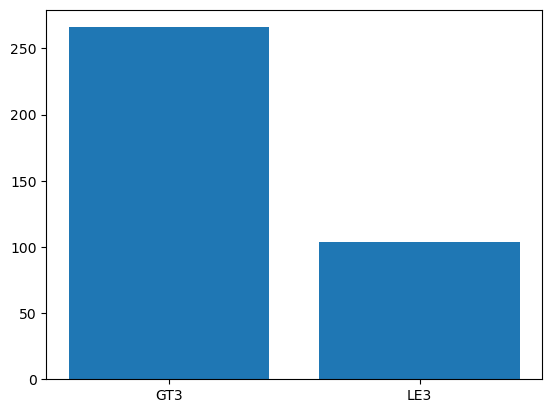

In [5]:
#plot the variable famsize by its subgroups in counts

fs_values = df.famsize.value_counts()
plt.bar(fs_values.index, fs_values.values)

The dichotomous variable famsize contains data on the students who have more than three people in their family (GT3), or less than or equal to three people in their family (LE3). This will be the dependent variable for the logistic regression.

The predictors will be the final grades in both maths (mG3) and portuguese (pG3).

##  Logistic Regression

The logistic regression will look at whether the final portuguese grade pG3 can predict the family size (famsize).



First, the data is encoded so that the values of famsize are represented numerically. This means that the values of GT3 and LE3 will be encoded as 0 and 1.

In [6]:
# encode famsize numerically
df['famsize_numeric'] = pd.get_dummies(df.famsize).astype(int)['GT3']
prop_gt3 = sum(df.famsize_numeric)/len(df)
print(f'Proportion of GT3 values: {prop_gt3:.3f}')
df

Proportion of GT3 values: 0.719


,Unnamed: 0,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,...,freetime,goout,Dalc,Walc,health,absences.p,pG1,pG2,pG3,famsize_numeric
0,0,GP,F,15,R,GT3,T,1,1,at_home,...,1,2,1,1,1,4,13,13,13,1
1,1,GP,F,15,R,GT3,T,1,1,other,...,3,4,2,4,5,2,13,11,11,1
2,2,GP,F,15,R,GT3,T,2,2,at_home,...,3,1,1,1,2,8,14,13,12,1
3,3,GP,F,15,R,GT3,T,2,4,services,...,3,2,1,1,5,2,10,11,10,1
4,4,GP,F,15,R,GT3,T,3,3,services,...,2,1,2,3,3,2,13,13,13,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
365,377,MS,M,18,U,LE3,T,1,3,at_home,...,3,3,2,3,3,0,9,10,9,0
366,378,MS,M,18,U,LE3,T,4,4,teacher,...,2,2,2,2,5,0,15,16,16,0
367,379,MS,M,19,R,GT3,T,1,1,other,...,4,4,3,3,5,4,8,9,10,1
368,380,MS,M,19,R,GT3,T,1,1,other,...,4,4,3,3,2,8,10,9,11,1


#### Baseline Model

A baseline linear regression model is made for comparison purposes. It only fits the constant coefficient. It will always predict the same value as all fitted values are the same.

In [7]:
# Baseline model
logbase_m = smf.logit("famsize_numeric ~ 1", data=df).fit()
logbase_m.summary()

Optimization terminated successfully.
         Current function value: 0.593971
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        famsize_numeric   No. Observations:                  370
Model:                          Logit   Df Residuals:                      369
Method:                           MLE   Df Model:                            0
Date:                Fri, 22 Dec 2023   Pseudo R-squ.:               6.528e-11
Time:                        06:24:34   Log-Likelihood:                -219.77
converged:                       True   LL-Null:                       -219.77
Covariance Type:            nonrobust   LLR p-value:                       nan
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9391      0.116      8.120      0.000       0.712       1.166
==============================================================================
"""

In [8]:
# intercept - log-odds
math.log(prop_gt3/(1-prop_gt3))

0.9391054096403263

In [9]:
# all predictions are the same and equal to proportion
logbase_m.predict()[:20]

array([0.71891892, 0.71891892, 0.71891892, 0.71891892, 0.71891892,
       0.71891892, 0.71891892, 0.71891892, 0.71891892, 0.71891892,
       0.71891892, 0.71891892, 0.71891892, 0.71891892, 0.71891892,
       0.71891892, 0.71891892, 0.71891892, 0.71891892, 0.71891892])

In [10]:
# Deviance of baseline model
logbase_dev = -2 * logbase_m.llf
print(f'Deviance of baseline model: {logbase_dev:.2f}')

Deviance of baseline model: 439.54


## Model
The logistic regression is fitted with the final grade pG3 as a predictor of family size (famsize).

In [11]:
# Actual model
loganx_m = smf.logit("famsize_numeric ~ pG3", data=df).fit()
loganx_m.summary()

Optimization terminated successfully.
         Current function value: 0.593332
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        famsize_numeric   No. Observations:                  370
Model:                          Logit   Df Residuals:                      368
Method:                           MLE   Df Model:                            1
Date:                Fri, 22 Dec 2023   Pseudo R-squ.:                0.001077
Time:                        06:24:34   Log-Likelihood:                -219.53
converged:                       True   LL-Null:                       -219.77
Covariance Type:            nonrobust   LLR p-value:                    0.4914
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.2850      0.522      2.464      0.014       0.263       2.307
pG3           -0.0274      0.040     -0.683      0.495      -0.106       0.051
==============================================================================
"""

#### Model Visualisation

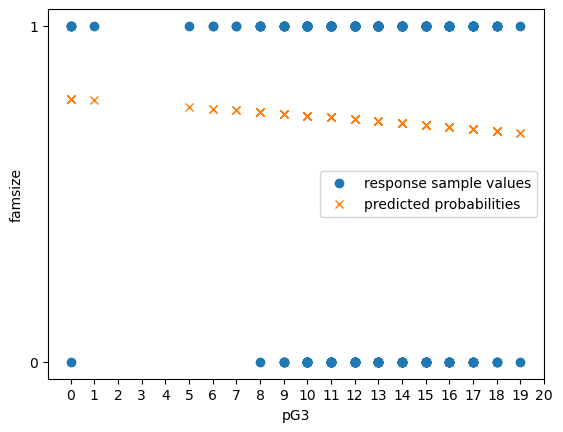

In [12]:
# Visualise model
plt.plot(df.pG3, df.famsize_numeric, "o")
plt.plot(df.pG3, loganx_m.predict(), "x")
plt.xlabel("pG3")
plt.ylabel("famsize")
plt.xticks(range(0, 21))
plt.yticks(range(0,2))
plt.legend(["response sample values", "predicted probabilities"])


The plot shows the real values of instances of family size being greater than 3, or less than 3. The predicted probabilities are also shown.

#### Model Evaluation


##### Capture of variability

In [13]:
# Deviance improvement
-2*(loganx_m.llnull - loganx_m.llf), loganx_m.llr

(0.4734742158638596, 0.4734742158638596)

In [14]:
# chi squared test

df_resid = logbase_m.df_resid - loganx_m.df_resid
pvalue = 1 - ss.chi2.cdf(loganx_m.llr, df_resid)
pvalue, loganx_m.llr_pvalue



(0.4913931937291611, 0.4913931937291611)

McFadden pseudo $R^2$ is 0.001077. This is very low and means that the model does not explain much of the variance of the family sizes  well. 

Based on the chi-squared test: 
The p-value (*p* = 0.49) is very large and indicates that the addition of the final grades as a predictor has  not significantly improved the model.

 

##### Coefficients

In [15]:
#odds ratio of the coefficient in the model
exp_v = np.vectorize(math.exp)
pd.DataFrame({'coefficient': loganx_m.params[1:], 'odds ratio': exp_v(loganx_m.params[1:])})

,coefficient,odds ratio
pG3,-0.027437,0.972936


The z value of the final portuguese grades is not significant at the 0.05 level (*z* = -.683)

The odds ration of 0.972 means that for every unit of portuguese final grade increase, the odds of a family size being greater than 3 decrease by a factor of 0.97

##### Prediction success

In [16]:
predicted = (loganx_m.predict() > 0.5).astype(int)
loganx_m.pred_table(), sum(predicted == df.famsize_numeric)/len(df)

(array([[  0., 104.],
        [  0., 266.]]),
 0.7189189189189189)

 The model identifies nothing but false negatives correctly as it only ever predicts one value when thresholded to 0.5, making the model identical to the baseline.

0.5043016194331984


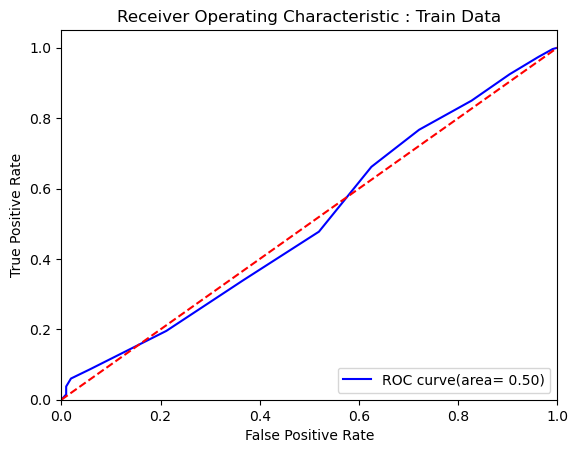

In [17]:
#loganx_m.predict()

roc_auc_train = sklm.roc_auc_score(df['famsize_numeric'], predicted)
fpr, tpr, threshold = sklm.roc_curve(df['famsize_numeric'], loganx_m.predict())
roc_auc = sklm.auc(fpr, tpr)
print(roc_auc)
plt.figure()
plt.plot(fpr,tpr,color ='blue',label='ROC curve(area= %0.2f)'%(roc_auc))
plt.plot([0,1],[0,1],'r--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("Receiver Operating Characteristic : Train Data")
plt.legend(loc='lower right')
plt.show()

The ROC curve indicates that the model is no different than random guessing.

In conclusion, the model is not much better than random guessing at the task of predicting the family size based on the final grade.

### Assumptions

Logistic Regression Assumptions:
- Linearity
- Independence of errors
- Absence of multicollinearity

#### No perfect multicollinearity

In [18]:
# the second argument are the indices of the independent variables that need to be tested
smi.variance_inflation_factor(loganx_m.model.exog, 1)

0.9999999999999998

Values of VIF between 5 and 10 are moderate and over 10 not acceptable.

A value of 1 indicates that multicoliniarity is not an issue. 

#### Independent errors
Data is assumed to be independent as each instance was collected from different students.

#### Linearity

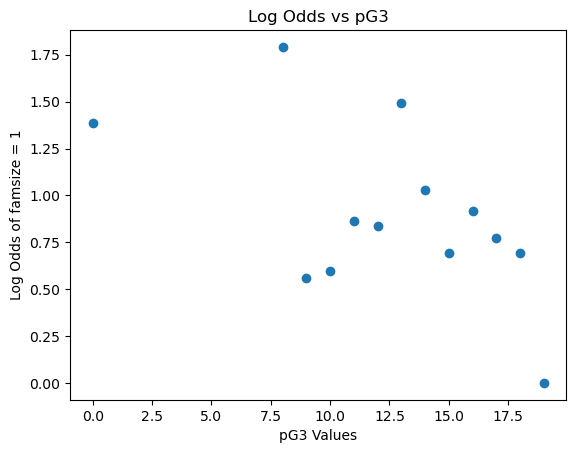

In [19]:
lincheck_df = pd.DataFrame({'bin_vals': range(21)})

def log_odds(p):
    if p == 0 or p== 1: 
        return np.nan
    return math.log(p / (1 - p))

# Calculate log-odds
lincheck_df['log_odds'] = [log_odds(len(g[g.famsize_numeric == 1]) / len(g)) if len(g) > 0 else np.nan 
                           for g in (df[df.pG3 == a] for a in lincheck_df['bin_vals'])]

# Drop rows with NaN
lincheck_df = lincheck_df.dropna()

# Plot
plt.plot(lincheck_df.bin_vals, lincheck_df.log_odds, "o")
plt.xlabel('pG3 Values')
plt.ylabel('Log Odds of famsize = 1')
plt.title('Log Odds vs pG3')
plt.show()

The plot shows a roughly negative linear relationship between the number of students and the number of hours they spend studying. This suggests that there may be a relationship between the final portuguese grades and the logodds of the family size.

### Diagnostics:

Cooke's distance is used to identify influential instances of student data.

In [20]:
#Cook's distance
loganx_m2 = smf.glm("famsize_numeric ~ pG3", data=df, family=sm.families.Binomial(link=sm.families.links.Logit())).fit()
cooks_d_list = loganx_m2.get_influence().cooks_distance[0]
sorted(cooks_d_list)[::-1][:20]

[0.09171991126121161,
 0.018847119829236158,
 0.014433315157009947,
 0.014433315157009947,
 0.014433315157009947,
 0.013643090987177866,
 0.01074509613166463,
 0.01074509613166463,
 0.01074509613166463,
 0.01074509613166463,
 0.01074509613166463,
 0.01074509613166463,
 0.009673528096842104,
 0.009673528096842104,
 0.009673528096842104,
 0.009673528096842104,
 0.007790590230790792,
 0.007790590230790792,
 0.007790590230790792,
 0.007790590230790792]

In [21]:
print("Min:", cooks_d_list.min())
print("Max:", cooks_d_list.max())
print("Mean:", cooks_d_list.mean())

Min: 0.0005466053843808995
Max: 0.09171991126121161
Mean: 0.0027006328331163135


A low mean cook's distance suggests that the outliers are not very influential.

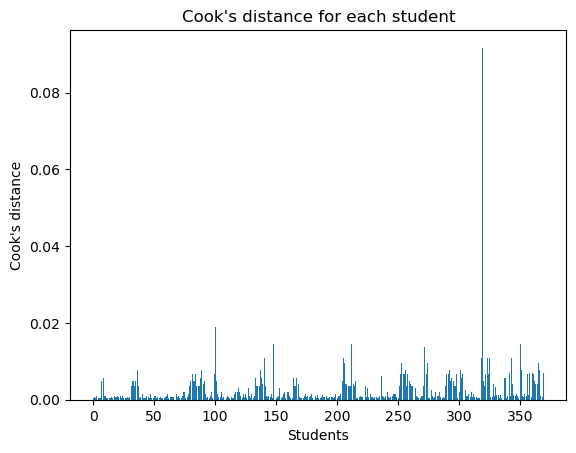

In [22]:
plt.bar(range(0, len(cooks_d_list)), cooks_d_list)
plt.title('Cook\'s distance for each student')
plt.xlabel('Students')
plt.ylabel('Cook\'s distance')

plt.show()

In [23]:
high_cooks_distance_students = {i: dist for i, dist in enumerate(cooks_d_list) if dist > 0.01}

top_cooks_df = df.loc[high_cooks_distance_students.keys()][["famsize", "pG3"]]

top_cooks_df

,famsize,pG3
100,LE3,19
140,LE3,17
148,LE3,18
205,LE3,17
212,LE3,18
272,LE3,8
318,LE3,17
319,LE3,0
323,LE3,17
325,LE3,17


Cook's distance shows only one particularly notable outlier. This is a student with a small family who has recieved a 0 grade for pG3. Less notable instances are where the grade is particularly high (< 17) and the student has a small family. 

### Report

A logistic regression was carried out to investigate if the final grade in Portuguese predicted the student's family size. It was found that the prediction was not significant, with deviance improvement from the baseline of $\chi^2(1)=0.47$, p = *p* = .49), R$^2$ = 0.001077. 

The model is not particularly good at predicting the family size based on the final grade in portuguese.  

The assumptions for the linear regression were met.
